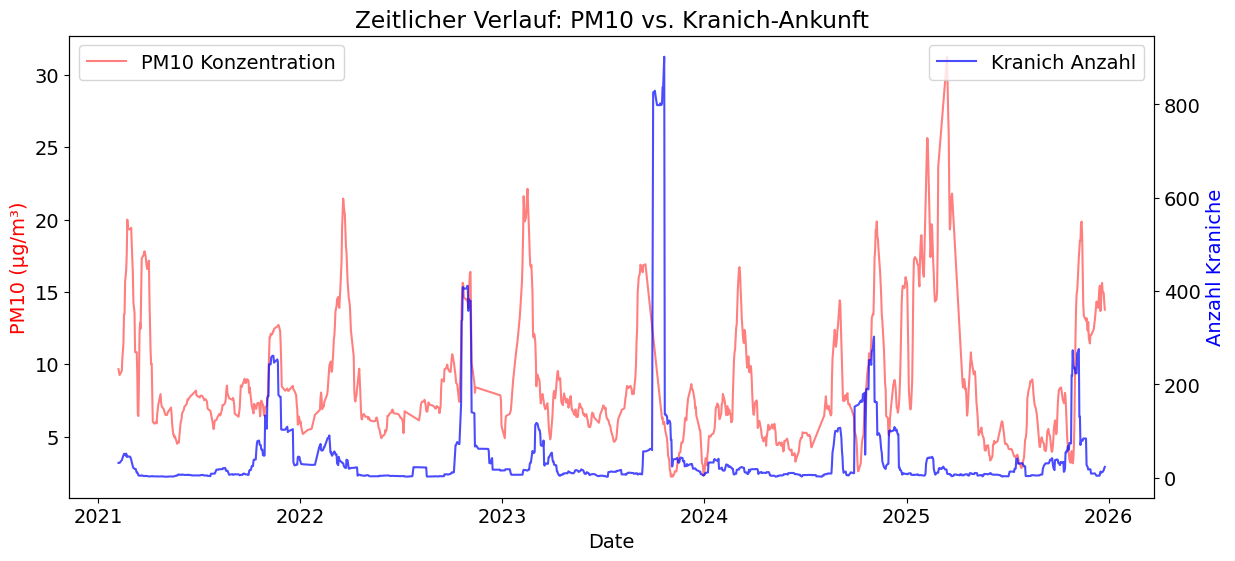

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reading in the data and preparing it so we can work with it
df = pd.read_csv('craneCount_pollution_arrivalDates_2021-2025.csv')
df['Date'] = pd.to_datetime(df['Date'])

# § LLM Help for Making sure that Is_Arrival_Day is a bool or string
df['Is_Arrival_Day'] = df['Is_Arrival_Day'].fillna(False).astype(bool)

# § LLM Help Smoothing our Count and PM10 data by taking the mean of every 14 days
df['PM10_smooth'] = df['PM10'].rolling(window=14, center=True).mean()
df['Count_smooth'] = df['Count'].rolling(window=14, center=True).mean()

# Making our Dual-AXis chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# § LLM Help to set up the axises
ax2 = ax1.twinx()
sns.lineplot(data=df, x='Date', y='PM10_smooth', ax=ax1, color='red', alpha=0.5, label='PM10 Konzentration')
sns.lineplot(data=df, x='Date', y='Count_smooth', ax=ax2, color='blue', alpha=0.7, label='Kranich Anzahl')

# Putting in our lines
ax1.set_ylabel('PM10 (µg/m³)', color='red')
ax2.set_ylabel('Anzahl Kraniche', color='blue')
plt.title('Zeitlicher Verlauf: PM10 vs. Kranich-Ankunft')

plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Loading and preparing our data to work with it
df = pd.read_csv('craneCount_pollution_arrivalDates_2021-2025.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Is_Arrival_Day'] = df['Is_Arrival_Day'].astype(str).str.lower().str.strip()
df = df[df['Date'].dt.month <= 4].copy()

# Making Categories for the box plot
df['Category'] = 'Restliche Zeit'
df.loc[df['Is_Arrival_Day'] == 'yes', 'Category'] = 'Ankunftstag'

# § LLM Help for Getting our 14 days before the arrival dates to put them a category
arrival_dates = df[df['Is_Arrival_Day'] == 'yes']['Date'].unique()
for arrival_date in arrival_dates:
    mask = (df['Date'] >= arrival_date - pd.Timedelta(days=14)) & (df['Date'] < arrival_date)
    df.loc[mask & (df['Category'] == 'Restliche Zeit'), 'Category'] = '14 Tage vor Ankunft'

# Creating our Box Plot
fig = go.Figure()

pollutants = ['PM10', 'PM2.5', 'O3']
categories = ['Restliche Zeit', '14 Tage vor Ankunft', 'Ankunftstag']
colors = ["#bdc3c7", "#f1c40f", "#2ecc71"]

# Create boxplots for each pollutant and category
for poll in pollutants:
    for i, cat in enumerate(categories):
        # § LLM Help to Filter data for current pollutant and category
        plot_data = df[df['Category'] == cat][poll]
        
        fig.add_trace(go.Box(
            y=plot_data,
            x=[cat] * len(plot_data),
            name=cat,
            visible=(poll == 'PM10'),
            marker=dict(color='black', opacity=0.4, size=4),
            line=dict(color='black', width=2),
            fillcolor=colors[i],
            boxpoints='all',
            jitter=0.3,
            pointpos=0,
            showlegend=False
        ))

# § LLM Help for Creating the interactive dropdown menu
buttons = []
for i, poll in enumerate(pollutants):
    # § LLM Help to Create visibility array for all traces and make only the three traces of current pollutant visible
    visibility = [False] * (len(pollutants) * len(categories))
    visibility[i*3 : (i+1)*3] = [True, True, True]
    
    buttons.append(dict(
        label=f"Schadstoff: {poll}",
        method="update",
        args=[{"visible": visibility},
              {"title": f"Konzentration von {poll} (Januar - April)"}]
    ))

# layout for the box plot
fig.update_layout(
    # § LLM Help for Making the dropdown menu
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.5, xanchor="center", y=1.15, yanchor="top", 
        showactive=True
    )],
    title=f"Konzentration von {pollutants[0]} (Januar - April)",
    title_x=0.5, 
    template="plotly_white",
    yaxis_title="Konzentration (µg/m³)",
    xaxis=dict(type='category'),
    boxgap=0.1,     
    boxgroupgap=0.1  
)

# Increasing the widht of the boxes
fig.update_traces(width=0.6) 

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Loading data and preparing it
df = pd.read_csv('craneCount_pollution_arrivalDates_2021-2025.csv')
df['Date'] = pd.to_datetime(df['Date'])

# § LLM Help to Extract date components for easier filtering and grouping
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

# Filter data from January to march
df_filtered = df[df['Month'] <= 3].copy()

# § LLM Help for Making a 7 day smoothing
df_filtered['Count_Smooth'] = df_filtered.groupby('Year')['Count'].transform(lambda x: x.rolling(window=7, center=True).mean())
df_filtered['PM10_Smooth'] = df_filtered.groupby('Year')['PM10'].transform(lambda x: x.rolling(window=7, center=True).mean())

# § LLM Help for a DummyDate for the mutual x axis
df_filtered['DummyDate'] = df_filtered['Date'].apply(lambda x: x.replace(year=2024))

# § LLM Help for Calculating the average over all years
avg_data = df_filtered.groupby('DayOfYear').agg({
    'PM10_Smooth': 'mean', 
    'Count_Smooth': 'mean', 
    'DummyDate': 'first'
}).reset_index()

# Making the interactiv plot (with secondary y-axis)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Get unique years and define colors
years = sorted(df_filtered['Year'].unique())
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

# Add traces for each year
for i, year in enumerate(years):
    # Filter data for current year and sort by day of year
    yearly_df = df_filtered[df_filtered['Year'] == year].sort_values('DayOfYear')
    
    # § LLM Help to Add smoothed crane count line
    fig.add_trace(
        go.Scatter(x=yearly_df['DummyDate'], y=yearly_df['Count_Smooth'], 
                   name=f'Kraniche {year}', line=dict(color=colors[i], width=2.5),
                   legendgroup=f'group{year}'),
        secondary_y=True
    )
    
    # § LLM Help to Add smoothed PM10 line
    fig.add_trace(
        go.Scatter(x=yearly_df['DummyDate'], y=yearly_df['PM10_Smooth'], 
                   name=f'PM10 {year}', line=dict(color=colors[i], width=1, dash='dot'),
                   opacity=0.4, legendgroup=f'group{year}', showlegend=False),
        secondary_y=False
    )
    
    # § LLM Help to Add arrival day markers
    arrivals = yearly_df[yearly_df['Is_Arrival_Day'].astype(str).str.lower().str.strip() == 'yes']
    fig.add_trace(
        go.Scatter(x=arrivals['DummyDate'], y=arrivals['Count_Smooth'],
                   mode='markers', name=f'Ankunft {year}',
                   marker=dict(symbol='star', size=12, color=colors[i], line=dict(width=1, color='black')),
                   legendgroup=f'group{year}', showlegend=False),
        secondary_y=True
    )

# Add average lines
fig.add_trace(
    go.Scatter(x=avg_data['DummyDate'], y=avg_data['Count_Smooth'], 
               name='Ø Kraniche (Gesamt)', line=dict(color='black', width=3),
               legendgroup='avg'),
    secondary_y=True
)

fig.add_trace(
    go.Scatter(x=avg_data['DummyDate'], y=avg_data['PM10_Smooth'], 
               name='Ø PM10 (Gesamt)', line=dict(color='black', width=2, dash='dash'),
               legendgroup='avg', showlegend=False),
    secondary_y=False
)

# Update general layout
fig.update_layout(
    title='Geglättete Kranich-Ankunft & PM10 (Jan - Mär, 7-Tage-Schnitt)',
    xaxis_title='Zeitraum (Januar bis März)',
    xaxis=dict(tickformat='%b', range=['2024-01-01', '2024-03-31']),
    hovermode='x unified',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.1)
)

# Configure y-axes
fig.update_yaxes(title_text="PM10 Konzentration (geglättet)", secondary_y=False)
fig.update_yaxes(title_text="Anzahl Kraniche (geglättet)", secondary_y=True)

fig.show()